# ⚽ Field Detection — Developer Guide

This notebook detects soccer pitch lines, estimates camera extrinsics/intrinsics,
and produces a top-down (bird's-eye) projection.

Structure:
- Utility drawing helpers
- 3D field point definitions (KeyPoints)
- Projection helpers (project_to_screen + drawing)
- Line detection (edges/contours/Hough)
- Calibration routines (estimation of K, R, t)
- `process_media` pipeline for video/image processing

Each section below contains a short demo cell showing intermediate outputs for debugging.


## Utilities: drawing & geometric helpers

Small helpers to draw points/lines and compute line intersections.
Used throughout the visualization/debug pipeline.


In [6]:
import cv2
import numpy as np


def draw_point(img, point):
    """Draw key point with opencv on image"""
    if point is None:
        return img
    img = cv2.circle(
        img,
        center=(int(point[0]), int(point[1])),
        radius=5,
        color=(0, 0, 255),
        thickness=5,
    )

    return img


def draw_line(img, line, color="red"):
    """Draw unlimited line on image with some color
    Line is defined in polar coordinates
    """

    if line is None:
        return img

    rho = line[0]
    theta = line[1]
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a * rho
    y0 = b * rho
    pt1 = (int(x0 + 2000 * (-b)), int(y0 + 2000 * (a)))
    pt2 = (int(x0 - 2000 * (-b)), int(y0 - 2000 * (a)))
    bgr = (255, 255, 255)
    if color == "red":
        bgr = (0, 0, 255)
    elif color == "blue":
        bgr = (255, 0, 0)
    elif color == "green":
        bgr = (0, 255, 0)
    cv2.line(img, pt1, pt2, bgr, 3, cv2.LINE_AA)

    return img


def intersect(line_1, line_2):
    """
    Find intersection of two lines
    """

    if line_1 is None or line_2 is None:
        return None

    rho_1 = line_1[0]
    theta_1 = line_1[1]
    rho_2 = line_2[0]
    theta_2 = line_2[1]

    if theta_1 == theta_2:
        return None

    u = (rho_1 * np.sin(theta_2) - rho_2 * np.sin(theta_1)) / np.sin(theta_2 - theta_1)
    if theta_1 != 0:
        v = (rho_1 - u * np.cos(theta_1)) / np.sin(theta_1)
    else:
        v = (rho_2 - u * np.cos(theta_2)) / np.sin(theta_2)

    return [int(u), int(v)]


## KeyPoints: 3D coordinates for standard pitch features

This class centralizes canonical 3D world coordinates for pitch keypoints
(center circle, penalty box corners, midline, goals). Coordinates are expressed
in a pitch-centric world frame (origin at pitch center) — used to generate
expected 2D projections.


In [5]:
import numpy as np

# Points in world with origin au centre, x going right, y to the foreground, z to the top
# Positions are based on official soccer dimensions
right_circle_world = [9.15, 0, 0]
left_circle_world = [-9.15, 0, 0]
behind_circle_world = [0, 0, 9.15]
front_circle_world = [0, 0, -9.15]
front_middle_line_world = [0, 0, -34]
back_middle_line_world = [0, 0, 34]

corner_back_left_world = [-52.5, 0, 34]
corner_front_left_world = [-52.5, 0, -34]
corner_back_right_world = [52.5, 0, 34]
corner_front_right_world = [52.5, 0, -34]


DIST_TO_CENTER = 77.0


class KeyPoints:
    """
    Class of key points to be used to solve the PnP
    and estimate the focal length
    """

    def __init__(self):
        self.right_circle = None
        self.left_circle = None
        self.behind_circle = None
        self.front_circle = None
        self.front_middle_line = None
        self.back_middle_line = None
        self.corner_back_left = None
        self.corner_back_right = None
        self.corner_front_left = None
        self.corner_front_right = None

    def draw(self, img):
        """Draw all key points on image"""
        img = draw_point(img, self.right_circle)
        img = draw_point(img, self.left_circle)
        img = draw_point(img, self.behind_circle)
        img = draw_point(img, self.front_circle)
        img = draw_point(img, self.front_middle_line)
        img = draw_point(img, self.back_middle_line)
        img = draw_point(img, self.corner_back_left)
        img = draw_point(img, self.corner_back_right)
        img = draw_point(img, self.corner_front_left)
        img = draw_point(img, self.corner_front_right)

        return img

    def __str__(self):
        return (
            f"Right circle: {self.right_circle}\nLeft circle: {self.left_circle}\n"
            f"Behing circle: {self.behind_circle}\nFront circle: {self.front_circle}\n"
            f"Back middle line: {self.back_middle_line}\n"
            f"Front middle line: {self.front_middle_line}\n"
            f"Corner back left: {self.corner_back_left}\n"
            f"Corner back right: {self.corner_back_right}\n"
            f"Corner front left: {self.corner_front_left}\n"
            f"Corner front right: {self.corner_front_right}\n"
        )

    def make_2d_3d_association_list(self):
        """
        Define set of pixels (2D) and its correspondance of points in world (3D)
        to feed the PnP solver.
        """
        pixels = []
        points_world = []

        if self.right_circle is not None:
            pixels.append(self.right_circle)
            points_world.append(right_circle_world)
        if self.left_circle is not None:
            pixels.append(self.left_circle)
            points_world.append(left_circle_world)
        if self.behind_circle is not None:
            pixels.append(self.behind_circle)
            points_world.append(behind_circle_world)
        if self.front_circle is not None:
            pixels.append(self.front_circle)
            points_world.append(front_circle_world)
        if self.front_middle_line is not None:
            pixels.append(self.front_middle_line)
            points_world.append(front_middle_line_world)
        if self.back_middle_line is not None:
            pixels.append(self.back_middle_line)
            points_world.append(back_middle_line_world)
        if self.corner_front_left is not None:
            pixels.append(self.corner_front_left)
            points_world.append(corner_front_left_world)
        if self.corner_front_right is not None:
            pixels.append(self.corner_front_right)
            points_world.append(corner_front_right_world)
        if self.corner_back_left is not None:
            pixels.append(self.corner_back_left)
            points_world.append(corner_back_left_world)
        if self.corner_back_right is not None:
            pixels.append(self.corner_back_right)
            points_world.append(corner_back_right_world)

        pixels = np.array(pixels, dtype=np.float32)
        points_world = np.array(points_world)

        return pixels, points_world

    def compute_focal_length(self, guess_fx):
        """
        Compute the focal length based on the central circle.
        If we cant spot the central circle, we return the default incoming value
        """
        if self.right_circle is None and self.left_circle is None:
            return guess_fx

        if self.right_circle is not None and self.left_circle is not None:
            fx = (
                (self.right_circle[0] - self.left_circle[0])
                * DIST_TO_CENTER
                / (right_circle_world[0] - left_circle_world[0])
            )
            return fx

        if self.behind_circle is None or self.front_circle is None:
            return guess_fx

        central = [
            int((self.behind_circle[0] + self.front_circle[0]) / 2),
            int((self.behind_circle[1] + self.front_circle[1]) / 2),
        ]
        if self.right_circle is None:
            fx = (
                (central[0] - self.left_circle[0])
                * DIST_TO_CENTER
                / (-left_circle_world[0])
            )
            return fx

        if self.left_circle is None:
            fx = (
                (self.right_circle[0] - central[0])
                * DIST_TO_CENTER
                / (right_circle_world[0])
            )
            return fx

        return guess_fx


## Projection helpers — projecting 3D points to image plane

`project_to_screen` and `project_and_draw_lines` transform 3D pitch points
to 2D image coordinates using intrinsic matrix K and extrinsics (R, t).
The draw_* helpers render idealized pitch lines for comparison with detected lines.


In [7]:
import numpy as np
import cv2

def project_to_screen(K, to_device_from_world, point_in_world):
    """
    Project point_in_world to the screen and returns pixel coordinates
    """
    homog = np.ones((4, 1))
    homog[0:3, 0] = point_in_world
    point_in_device = np.dot(to_device_from_world, homog)
    point_in_device_divided_depth = (point_in_device / point_in_device[2, 0])[0:3]
    point_projected = np.dot(K, point_in_device_divided_depth)
    return [int(point_projected[0]), int(point_projected[1])]


def project_and_draw_lines(K, to_device_from_world, points_in_world, img):
    """Project list of points in world and draw polyline"""

    projected_points = []
    for point_in_world in points_in_world:
        projected_points.append(
            project_to_screen(K, to_device_from_world, np.array(point_in_world))
        )

    nb_pts = len(projected_points)
    for i in range(nb_pts):
        img = cv2.line(
            img,
            projected_points[i],
            projected_points[(i + 1) % nb_pts],
            color=(0, 165, 255),
            thickness=3,
        )

    return img


def draw_central_circle(K, to_device_from_world, img):
    """Draw central circle on the image"""

    circle_radius = 9.15

    res = 25
    circle_points_projected = np.zeros((res, 2), dtype=np.int32)
    for i in range(res):
        angle = i / res * np.pi * 2
        circle_points_world = (
            np.array([np.cos(angle), 0, np.sin(angle)]) * circle_radius
        )
        circle_points_projected[i] = project_to_screen(
            K, to_device_from_world, circle_points_world
        )

    img = cv2.polylines(
        img, [circle_points_projected], isClosed=True, color=(0, 165, 255), thickness=3
    )

    return img


def draw_middle_line(K, to_device_from_world, img):
    """Draw middle/main line"""

    img = project_and_draw_lines(
        K,
        to_device_from_world,
        [
            back_middle_line_world,
            front_middle_line_world,
        ],
        img,
    )

    return img


def draw_border_lines(K, to_device_from_world, img):
    """Draw border lines"""

    img = project_and_draw_lines(
        K,
        to_device_from_world,
        [
            corner_back_left_world,
            corner_front_left_world,
            corner_front_right_world,
            corner_back_right_world,
        ],
        img,
    )

    return img


def draw_penalty_areas(K, to_device_from_world, img):
    """
    Draw penalty areas on both sides
    """

    penalty_left_front_goal_world = [-52.5, 0, -20.16]
    penalty_left_front_field_world = [-36, 0, -20.16]
    penalty_left_back_field_world = [-36, 0, 20.16]
    penalty_left_back_goal_world = [-52.5, 0, 20.16]

    img = project_and_draw_lines(
        K,
        to_device_from_world,
        [
            penalty_left_front_goal_world,
            penalty_left_front_field_world,
            penalty_left_back_field_world,
            penalty_left_back_goal_world,
        ],
        img,
    )

    penalty_right_front_goal_world = [52.5, 0, -20.16]
    penalty_right_front_field_world = [36, 0, -20.16]
    penalty_right_back_field_world = [36, 0, 20.16]
    penalty_right_back_goal_world = [52.5, 0, 20.16]

    img = project_and_draw_lines(
        K,
        to_device_from_world,
        [
            penalty_right_front_goal_world,
            penalty_right_front_field_world,
            penalty_right_back_field_world,
            penalty_right_back_goal_world,
        ],
        img,
    )

    return img


def draw_pitch_lines(K, to_device_from_world, img):
    """Draw pitch lines"""
    img = draw_central_circle(K, to_device_from_world, img)
    img = draw_middle_line(K, to_device_from_world, img)
    img = draw_border_lines(K, to_device_from_world, img)
    img = draw_penalty_areas(K, to_device_from_world, img)

    return img


## KeyLines: container for principal detected lines

`KeyLines` groups the main 5 field lines (back, front, middle, left, right)
and provides convenience drawing methods. These are the primary geometric constraints
used by calibration.


In [8]:
class KeyLines:
    """5 Key lines"""

    def __init__(self):
        self.front_line = None
        self.back_line = None
        self.main_line = None
        self.left_goal_line = None
        self.right_goal_line = None

    def draw(self, img):
        """Draw all lines on image"""
        img = draw_line(img, self.front_line, "red")
        img = draw_line(img, self.back_line, "red")
        img = draw_line(img, self.main_line, "green")
        img = draw_line(img, self.left_goal_line, "blue")
        img = draw_line(img, self.right_goal_line, "blue")

        return img


## Line and shape detection (image analysis)

Functions here detect candidate pitch lines:
- background/front line separation
- main line detection via Hough/contour heuristics
- central circle detection
- goal line detection
- assemble `KeyPoints`/`KeyLines` from image evidence


In [9]:
from argparse import ArgumentParser
from pathlib import Path
import cv2
import numpy as np

def find_back_front_lines(img):
    """
    Find back and front lines of the soccer pitch
    (where coach and linesmen are located)
    """

    height = img.shape[0]
    width = img.shape[1]

    # Use a standard canny before performing Hough lines detection
    dst = cv2.Canny(img, 50, 200, None, 3)

    lines = cv2.HoughLines(
        dst,
        1,
        np.pi / 180 / 4,
        500,
        None,
        min_theta=80 / 180 * np.pi,
        max_theta=100 / 180 * np.pi,
    )

    assert lines is not None

    # Loop over the lines to detect only one at the top and at the bottom of the image
    back_line_y = 0
    back_line = None
    front_line_y = height
    front_line = None
    for line in lines:
        rho = line[0][0]
        theta = line[0][1]
        a = np.cos(theta)
        b = np.sin(theta)
        y_middle = (rho - width / 2 * np.cos(theta)) / np.sin(theta)
        if back_line_y < y_middle < height / 2:
            back_line_y = y_middle
            back_line = line[0]
        if height / 2 < y_middle < front_line_y:
            front_line_y = y_middle
            front_line = line[0]

    # back and front line are here a tuple (rho, theta) in polar coordinates

    return back_line, front_line


def remove_out_of_field(img, back_line, front_line):
    """
    Remove every pixels outside of the back and front lines
    i.e. replace them by black pixels
    Return the modified image
    """

    if back_line is None and front_line is None:
        return img

    img_copy = img.copy()

    width = img_copy.shape[1]

    if back_line is None:
        rho_front = front_line[0]
        theta_front = front_line[1]
        for j in range(width):
            y_front = int((rho_front - j * np.cos(theta_front)) / np.sin(theta_front))
            img_copy[y_front:, j] = [0, 0, 0]
        return img_copy

    if front_line is None:
        rho_back = back_line[0]
        theta_back = back_line[1]
        for j in range(width):
            y_back = int((rho_back - j * np.cos(theta_back)) / np.sin(theta_back))
            img_copy[0:y_back, j] = [0, 0, 0]
        return img_copy

    rho_back = back_line[0]
    theta_back = back_line[1]
    rho_front = front_line[0]
    theta_front = front_line[1]
    for j in range(width):
        y_back = int((rho_back - j * np.cos(theta_back)) / np.sin(theta_back))
        y_front = int((rho_front - j * np.cos(theta_front)) / np.sin(theta_front))
        img_copy[0:y_back, j] = [0, 0, 0]
        img_copy[y_front:, j] = [0, 0, 0]

    # cv2.imshow("Lines removal", img_copy)
    # cv2.waitKey(0)

    return img_copy


def find_main_line(img):
    """
    Find the main line (~vertical line on the image)
    Return polar coordinates or None if no main line was found
    """

    # Use a canny/hough line detection to detect a vertical line
    dst = cv2.Canny(img, 50, 200, None, 3)
    # cv2.imshow("Canny", dst)
    # cv2.waitKey(0)

    # Copy edges to the images that will display the results in BGR
    cdst = cv2.cvtColor(dst, cv2.COLOR_GRAY2BGR)
    lines = cv2.HoughLines(
        dst,
        1,
        np.pi / 180 / 2,
        200,
        None,
        min_theta=0,
        max_theta=40 / 180 * np.pi,
    )

    lines_other = cv2.HoughLines(
        dst,
        1,
        np.pi / 180 / 2,
        250,
        None,
        min_theta=130 / 180 * np.pi,
        max_theta=np.pi,
    )

    if lines is not None:
        return lines[0][0]
    if lines_other is not None:
        return lines_other[0][0]
    return None


def find_central_circle(
    img, back_middle_point, front_middle_point, main_line, debug=False
):
    """
    Find central circle and return 4 'corners' of this circle.
    Use floodfilling in a Canny image to fill the circle.
    """

    if back_middle_point is None or front_middle_point is None:
        return None, None, None, None

    dst = cv2.Canny(img, 20, 100, None, 3)

    width = img.shape[1]
    if debug:
        cv2.imshow("Canny", dst)
        cv2.waitKey(0)

    # Copy the thresholded image.
    im_floodfill = dst.copy()

    # Dilate to have bolder contours
    im_floodfill = cv2.dilate(im_floodfill, kernel=np.ones((7, 7)))
    if debug:
        cv2.imshow("Dilatation", im_floodfill)
        cv2.waitKey(0)

    # Mask used to flood filling.
    h, w = dst.shape[:2]
    mask = np.zeros((h + 2, w + 2), np.uint8)

    # Floodfill from several points where we suspect the circle to be
    back_middle_point = np.array(back_middle_point)
    front_middle_point = np.array(front_middle_point)
    center_approx = 0.3 * front_middle_point + 0.7 * back_middle_point

    for seed in [-150, -100, -50, 50, 100, 150]:
        root = (int(center_approx[0]) + seed, int(center_approx[1]))
        if 0 <= root[0] < width:
            if im_floodfill[root[1], root[0]] != 0:
                continue
            cv2.floodFill(im_floodfill, mask, root, 128)

    if debug:
        cv2.imshow("Floodfill", im_floodfill)
        cv2.waitKey(0)

    final_mask = cv2.inRange(im_floodfill, 127, 129)
    # cv2.imshow("final_mask", final_mask)
    # cv2.waitKey(0)

    final_mask = cv2.dilate(final_mask, kernel=np.ones((15, 15)))
    final_mask = cv2.erode(final_mask, kernel=np.ones((10, 10)))
    # cv2.imshow("final_mask", final_mask)
    # cv2.waitKey(0)

    # Find contours around the filled area
    cnts = cv2.findContours(final_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = cnts[0] if len(cnts) == 2 else cnts[1]
    c = max(cnts, key=cv2.contourArea)
    left_circle = tuple(c[c[:, :, 0].argmin()][0])
    right_circle = tuple(c[c[:, :, 0].argmax()][0])
    y_top = tuple(c[c[:, :, 1].argmin()][0])[1]
    y_bottom = tuple(c[c[:, :, 1].argmax()][0])[1]

    behind_circle = [
        int((main_line[0] - y_top * np.sin(main_line[1])) / np.cos(main_line[1])),
        y_top,
    ]
    front_circle = [
        int((main_line[0] - y_bottom * np.sin(main_line[1])) / np.cos(main_line[1])),
        y_bottom,
    ]

    # It can happen that floodfilling was badely executed (wrong seed, little hole in the circle...)
    # so we must discard crazy situations
    if left_circle[0] == 0:
        left_circle = None
    elif left_circle[0] >= behind_circle[0] - 10:
        left_circle = None
    elif left_circle[0] >= front_circle[0] - 10:
        left_circle = None

    if right_circle[0] == img.shape[1] - 1:
        right_circle = None
    elif right_circle[0] <= behind_circle[0] + 10:
        right_circle = None
    elif right_circle[0] <= front_circle[0] + 10:
        right_circle = None

    if left_circle is not None:
        if (front_circle[0] - left_circle[0]) < 2 * (
            front_circle[1] - behind_circle[1]
        ):
            left_circle = None
    if right_circle is not None:
        if (right_circle[0] - front_circle[0]) < 2 * (
            front_circle[1] - behind_circle[1]
        ):
            right_circle = None

    if debug:
        cv2.imshow("FloodFill", img)
        cv2.waitKey(0)

    return left_circle, right_circle, behind_circle, front_circle


def find_goal_line(img, back_line, back_middle_point, left_line=False):
    """Find goal line based on the back_line position and the center
    left_line specifies if we are looking for the left or the right goal line
    """

    # Use parallel to back line (slightly below) to fit a line only in the area
    # between this line and the back line
    parallel_to_back_line = back_line.copy()
    parallel_to_back_line[0] = back_line[0] + 30 * back_line[1]

    height = img.shape[0]
    width = img.shape[1]

    img_copy = remove_out_of_field(img, back_line, parallel_to_back_line)

    if back_middle_point is not None:
        if left_line:
            for i in range(height):
                img_copy[i, back_middle_point[0] :] = [0, 0, 0]
        else:
            for i in range(height):
                img_copy[i, : int(back_middle_point[0])] = [0, 0, 0]

    dst = cv2.Canny(img_copy, 50, 200, None, 3)

    min_theta = 0 if left_line else 100 / 180 * np.pi
    max_theta = 80 / 180 * np.pi if left_line else np.pi
    lines = cv2.HoughLines(
        dst,
        1,
        np.pi / 180,
        60,
        None,
        min_theta=min_theta,
        max_theta=max_theta,
    )
    if lines is None:
        return None

    max_y_out = 0

    if left_line:
        for line in lines:
            rho = line[0][0]
            theta = line[0][1]
            y_out = rho / np.sin(theta)
            if y_out > max_y_out:
                max_y_out = y_out
                goal_line = line[0]
    else:
        for line in lines:
            rho = line[0][0]
            theta = line[0][1]
            y_out = (rho - width * np.cos(theta)) / np.sin(theta)
            if y_out > max_y_out:
                max_y_out = y_out
                goal_line = line[0]

    intersection_with_back_line_first = intersect(back_line, goal_line)

    # draw_line(img, goal_line, "green")

    dst = cv2.Canny(img, 50, 200, None, 3)
    # cv2.imshow("Canny", dst)
    # cv2.waitKey(0)

    # Second pass with larger hough detection
    lines = cv2.HoughLines(
        dst,
        1,
        np.pi / 180,
        200,
        None,
        min_theta=min_theta,
        max_theta=max_theta,
    )

    first_goal_line = goal_line.copy()

    if lines is None:
        return first_goal_line

    min_dist = 1000
    for line in lines:
        theta = line[0][1]
        if abs(theta - first_goal_line[1]) > 0.03:
            continue

        intersection_with_back_line = intersect(back_line, line[0])
        dist = np.linalg.norm(
            np.array(intersection_with_back_line)
            - np.array(intersection_with_back_line_first)
        )
        if dist < min_dist:
            goal_line = line[0]
            min_dist = dist

    # cv2.imshow("img", img)
    # cv2.waitKey(0)

    return goal_line


def find_key_points(img):
    """
    Find key points in image
    """
    width = img.shape[1]

    key_lines = KeyLines()

    key_lines.back_line, key_lines.front_line = find_back_front_lines(img)

    img_wo_out_of_field = remove_out_of_field(
        img, key_lines.back_line, key_lines.front_line
    )

    key_lines.main_line = find_main_line(img_wo_out_of_field)

    # key points can be found at the intersection
    key_points = KeyPoints()

    key_points.back_middle_line = intersect(key_lines.main_line, key_lines.back_line)
    key_points.front_middle_line = intersect(key_lines.main_line, key_lines.front_line)

    # Find central circle
    (
        key_points.left_circle,
        key_points.right_circle,
        key_points.behind_circle,
        key_points.front_circle,
    ) = find_central_circle(
        img,
        key_points.back_middle_line,
        key_points.front_middle_line,
        key_lines.main_line,
    )

    # Last step: detect goal line if there is one showing up
    if (
        key_points.back_middle_line is not None
        and key_points.back_middle_line[0] < width * 2 / 5
    ):
        key_lines.right_goal_line = find_goal_line(
            img, key_lines.back_line, key_points.back_middle_line, False
        )

    if (
        key_points.back_middle_line is not None
        and key_points.back_middle_line[0] > width * 3 / 5
    ):
        key_lines.left_goal_line = find_goal_line(
            img, key_lines.back_line, key_points.back_middle_line, True
        )

    if key_lines.right_goal_line is not None:
        key_points.corner_back_right = intersect(
            key_lines.right_goal_line, key_lines.back_line
        )
    if key_lines.left_goal_line is not None:
        key_points.corner_back_left = intersect(
            key_lines.left_goal_line, key_lines.back_line
        )

    return key_points, key_lines


## Calibration routines — estimate K, R, t

Key functions:
- `find_extrinsic_intrinsic_matrices`: estimates camera intrinsics (like fx) and extrinsics via correspondences.
- `calibrate_from_image`: wraps the optimization to fit world->image projection.
- Visualization helpers show yaw/focal length and produce top view.


In [10]:
from argparse import ArgumentParser
from pathlib import Path
import cv2
import numpy as np

def find_extrinsic_intrinsic_matrices(
    img, guess_fx, guess_rot, guess_trans, key_points
):
    """
    Given rough estimate of the focal length and of the camera pose, use PnP algorithm
    to optimally fit key_points (2D) with corresponding points on the pitch (3D)

    This returns the optimal focal length fx and the camera pose.
    """

    height, width = img.shape[0], img.shape[1]

    # Form the problem by associating pixels (2D) with points_world (3D)
    pixels, points_world = key_points.make_2d_3d_association_list()

    # PnP algo needs at least 4 points to work
    print(f"Solving PnP with {len(pixels)} points")

    # Build camera projection matrix
    fx = key_points.compute_focal_length(guess_fx)

    # Camera projection matrix
    K = np.array([[fx, 0, width / 2], [0, fx, height / 2], [0, 0, 1]])

    if pixels.shape[0] <= 3:
        print("Too few points to solve!")
        return None, K, guess_rot, guess_trans

    # Perspective-n-Point algorithm, returning rotation and translation vector
    (ret, rotation_vector, translation_vector) = cv2.solvePnP(
        points_world,
        pixels,
        K,
        distCoeffs=None,
        rvec=guess_rot,
        tvec=guess_trans,
        useExtrinsicGuess=True,
    )

    assert ret

    if np.isnan(rotation_vector[0, 0]):
        print("PnP could not be solved correctly --> Skip")
        return None, None, guess_rot, guess_trans

    # in the reference world
    to_device_from_world_rot = cv2.Rodrigues(rotation_vector)[0]

    # to_world_from_device
    camera_position_in_world = -np.matrix(to_device_from_world_rot).T * np.matrix(
        translation_vector
    )

    print(
        f"Camera is located at {-camera_position_in_world[1,0]:.1f}m high and "
        f"at {-camera_position_in_world[2,0]:.1f}m depth"
    )
    if fx is None:
        print(f"PnP outputed crazy value for focal length: {fx} --> Skip")
        return None, None, guess_rot, guess_trans

    dist_to_center = np.linalg.norm(camera_position_in_world)
    print(f"Final fx = {fx:.1f}. Distance to origin = {dist_to_center:.1f}m")
    if dist_to_center < 40.0 or dist_to_center > 100.0:
        print(
            f"PnP outputed crazy value for distance to center = {dist_to_center:.1f}m --> Skip"
        )
        return None, K, guess_rot, guess_trans

    # Build camera pose
    to_device_from_world = np.identity(4)
    to_device_from_world[0:3, 0:3] = to_device_from_world_rot
    to_device_from_world[0:3, 3] = translation_vector.reshape((3,))

    return to_device_from_world, K, rotation_vector, translation_vector


def find_closer_point_on_line(point, line):
    """Find closer point on a line to the given point"""
    rho = line[0]
    theta = line[1]
    point = np.array(point)

    pt_line_origin = np.array([0, rho / np.sin(theta)])
    a = point - pt_line_origin
    u = np.array([np.sin(theta), -np.cos(theta)])

    _lambda = np.dot(a, u)

    projected_point = pt_line_origin + _lambda * u

    projected_point = [int(projected_point[0]), int(projected_point[1])]

    return projected_point


def extend_key_points_set(key_points, K, to_device_from_world, key_lines):
    """
    As the PnP is not so performant with only a few points, we try to get closer
    to the Perspective-n-Line algo by projecting corners even if they are not visible

    We modifiy the key_points set.
    """

    if key_points.corner_back_right is None and key_points.corner_back_left is None:
        pt = project_to_screen(K, to_device_from_world, corner_front_right_world)
        key_points.corner_front_right = find_closer_point_on_line(
            pt, key_lines.front_line
        )
        pt = project_to_screen(K, to_device_from_world, corner_front_left_world)
        key_points.corner_front_left = find_closer_point_on_line(
            pt, key_lines.front_line
        )
        pt = project_to_screen(K, to_device_from_world, corner_back_right_world)
        key_points.corner_back_right = find_closer_point_on_line(
            pt, key_lines.back_line
        )
        pt = project_to_screen(K, to_device_from_world, corner_back_left_world)
        key_points.corner_back_left = find_closer_point_on_line(pt, key_lines.back_line)

    if (
        key_points.corner_back_right is not None
        and key_lines.right_goal_line is not None
    ):
        key_points.corner_front_right = intersect(
            key_lines.right_goal_line, key_lines.front_line
        )
    if key_points.corner_back_left is not None and key_lines.left_goal_line is not None:
        key_points.corner_front_left = intersect(
            key_lines.left_goal_line, key_lines.front_line
        )


def calibrate_from_image(img, guess_fx, guess_rot, guess_trans):
    """
    After selecting visible key_points, perform PnP algorithm a first time.
    Then, extend key points set by adding not visible corners of the soccer pitch,
    to enforce line fitting.
    Finally redo a PnP pass.
    """

    key_points, key_lines = find_key_points(img)

    assert not np.isnan(guess_rot[0, 0])

    to_device_from_world, K, guess_rot, guess_trans = find_extrinsic_intrinsic_matrices(
        img, guess_fx, guess_rot, guess_trans, key_points
    )

    if to_device_from_world is None:
        return K, to_device_from_world, guess_rot, guess_trans, img

    extend_key_points_set(key_points, K, to_device_from_world, key_lines)

    to_device_from_world, K, found_rot, found_trans = find_extrinsic_intrinsic_matrices(
        img, K[0, 0], guess_rot, guess_trans, key_points
    )

    return K, to_device_from_world, found_rot, found_trans, img


def display_yaw_and_focal_length(img, yaw, fx):
    """Display infos on image (yaw angle + fx)"""
    img = cv2.putText(
        img,
        f"Yaw: {yaw:.0f} deg, Focal: {fx:.0f}",
        (1280, 120),
        cv2.FONT_HERSHEY_COMPLEX,
        1,
        color=(0, 255, 0),
        thickness=2,
    )

    return img


def display_top_view(K, to_device_from_world, img):
    """
    Display top view of the image, by unprojecting every pixels of the image
    to its correspondance in the world, assuming that altitude is 0
    """

    height = img.shape[0]
    width = img.shape[1]

    # Top view
    width_soccer_field = 105
    height_soccer_field = 68
    unskewd = np.zeros((height, width, 3), np.uint8)
    pixels_width = int(width_soccer_field / height_soccer_field * height)
    offset_x = (width - pixels_width) // 2

    for i in range(height):
        z_world = -corner_front_left_world[2] - i * height_soccer_field / height
        for j in range(1668):

            x_world = corner_front_left_world[0] + j * width_soccer_field / pixels_width
            proj = project_to_screen(
                K, to_device_from_world, np.array([x_world, 0, z_world])
            )
            u = proj[0]
            v = proj[1]
            if 0 <= u < width and 0 <= v < height:
                unskewd[i, j + offset_x] = img[v, u]

    return unskewd


## Pipeline: `process_media`

This orchestrates reading frames (image or video), running detection,
calibration, and writing/displaying annotated or top-view outputs.
Parameters:
- input path
- output path (optional)
- show (display)
- top_view (boolean to choose top-down output)


In [11]:
import cv2
import numpy as np
from argparse import ArgumentParser
from pathlib import Path


def process_media(input_path, output_path=None, show=False, top_view=False):
    """
    Process an image or video to perform camera pose estimation and annotation.
    Optionally generates a top-down (bird’s-eye) view of the field.

    Args:
        input_path (str or Path): Path to an image or video file.
        output_path (str or Path): Path to save the annotated output.
        show (bool): Whether to display results in a window.
        top_view (bool): Whether to generate top-view (bird’s-eye) transformation.
    """

    # Default camera parameter guesses
    guess_fx = 2000
    guess_rot = np.array([[0.25, 0, 0]])
    guess_trans = (0, 0, 80)

    input_path = Path(input_path)

    if not input_path.exists():
        raise FileNotFoundError(f"Input path does not exist: {input_path}")

    # Detect if input is a video file
    video_exts = [".mp4", ".avi", ".mov", ".mkv"]
    is_video = input_path.suffix.lower() in video_exts

    if is_video:
        cap = cv2.VideoCapture(str(input_path))
        if not cap.isOpened():
            raise ValueError(f"Cannot open video file: {input_path}")

        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        fps = int(cap.get(cv2.CAP_PROP_FPS))
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

        if output_path is None:
            suffix = "_topview.mp4" if top_view else "_annotated.mp4"
            output_path = input_path.parent / f"{input_path.stem}{suffix}"

        out = cv2.VideoWriter(str(output_path), fourcc, fps, (width, height))

        frame_idx = 0
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            K, to_device_from_world, rot, trans, frame = calibrate_from_image(
                frame, guess_fx, guess_rot, guess_trans
            )

            if not top_view:
                # Regular annotated frame
                key_points, key_lines = find_key_points(frame)
                frame = key_points.draw(frame)

                if to_device_from_world is not None:
                    frame = draw_pitch_lines(K, to_device_from_world, frame)
                    frame = display_yaw_and_focal_length(
                        frame, guess_rot[0, 1] * 180 / np.pi, K[0, 0]
                    )
            else:
                # Bird's-eye / top view
                if to_device_from_world is not None:
                    frame = display_top_view(K, to_device_from_world, frame)

            # Update guesses for next frame
            if to_device_from_world is not None:
                guess_rot = rot
                guess_trans = trans
                guess_fx = K[0, 0]

            out.write(frame)

            if show:
                cv2.imshow("Output Frame", frame)
                if cv2.waitKey(1) & 0xFF == 27:
                    break

            frame_idx += 1
            if frame_idx % 30 == 0:
                print(f"Processed {frame_idx} frames...")

        cap.release()
        out.release()
        cv2.destroyAllWindows()
        print(f"✅ Output video saved to: {output_path}")

    else:
        # Process single image
        img = cv2.imread(str(input_path))
        if img is None:
            raise ValueError(f"Cannot read image: {input_path}")

        K, to_device_from_world, rot, trans, img = calibrate_from_image(
            img, guess_fx, guess_rot, guess_trans
        )

        if not top_view:
            key_points, key_lines = find_key_points(img)
            img = key_points.draw(img)
            if to_device_from_world is not None:
                img = draw_pitch_lines(K, to_device_from_world, img)
                img = display_yaw_and_focal_length(
                    img, guess_rot[0, 1] * 180 / np.pi, K[0, 0]
                )
        else:
            if to_device_from_world is not None:
                img = display_top_view(K, to_device_from_world, img)
            else:
                print("⚠️ Top-view unavailable: calibration failed.")

        if output_path:
            cv2.imwrite(str(output_path), img)
            print(f"✅ Output image saved to: {output_path}")
        if show:
            cv2.imshow("Output Image", img)
            cv2.waitKey(0)
            cv2.destroyAllWindows()


# 🎬 Demo: Full Field Detection and Top-View Pipeline

This section demonstrates the complete end-to-end flow:

1. Load a test frame or video.
2. Run the detection + calibration pipeline (`process_media`).
3. Display key intermediate results:
   - Original frame
   - Field mask (HSV segmentation)
   - Detected lines / contours
   - Reprojected field overlay
   - Top-view (bird’s-eye) transformation

You can replace the `input_path` variable with any video or single-frame path.


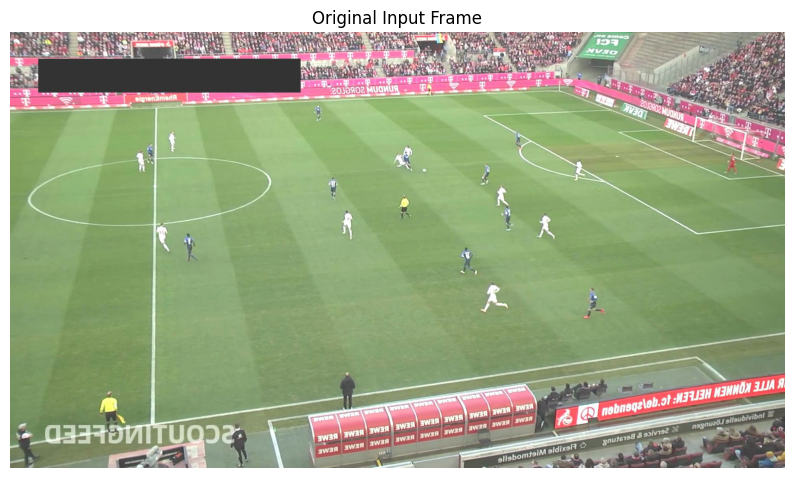

In [12]:
# === DEMO: Load sample image or first video frame ===
import cv2
import matplotlib.pyplot as plt

input_path = "/Users/alanpehz/Documents/Personal/True Computer Vision/FootballTracker/data/train/images/2e57b9_1_9_png.rf.4ddf27c8067f98fd10da07374f376097.jpg"  # <-- Replace this with your image or video path

# Try to read first frame (handles both image and video)
cap = cv2.VideoCapture(input_path)
if not cap.isOpened():
    frame = cv2.imread(input_path)
else:
    ret, frame = cap.read()
    cap.release()

if frame is None:
    raise ValueError("Failed to load demo image or video frame. Check input_path.")

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title("Original Input Frame")
plt.axis("off")
plt.show()


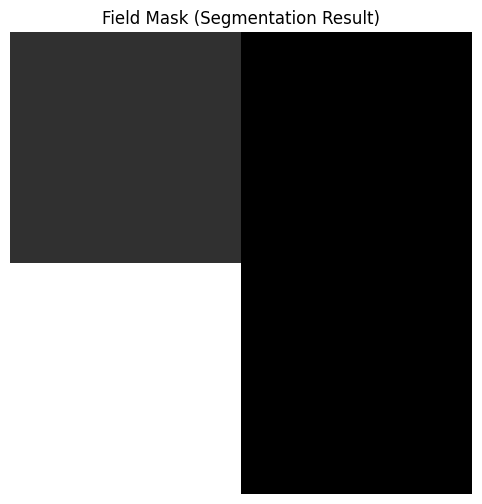

In [13]:
# === DEMO: Generate field mask ===
try:
    mask = find_back_front_lines(frame)
except Exception as e:
    print("Error running find_back_front_lines:", e)
    mask = None

if mask is not None:
    plt.figure(figsize=(10, 6))
    plt.imshow(mask, cmap="gray")
    plt.title("Field Mask (Segmentation Result)")
    plt.axis("off")
    plt.show()
else:
    print("Mask not available.")


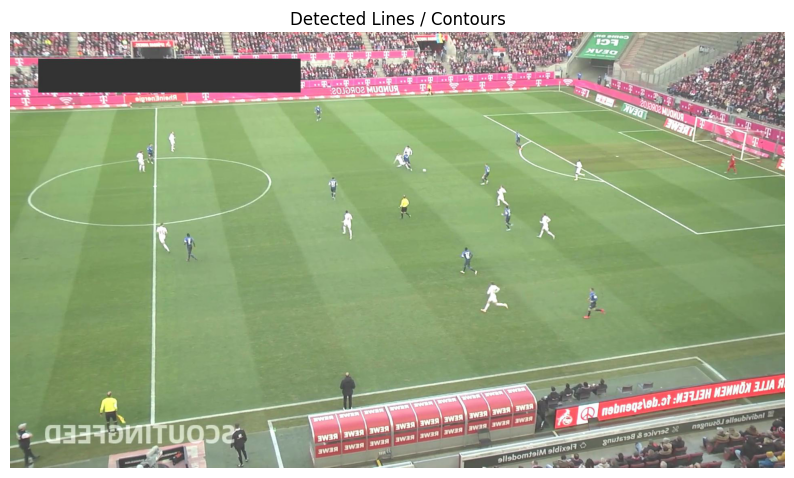

In [14]:
# === DEMO: Detect main lines and visualize on original frame ===
try:
    lines_info = find_main_line(frame) if 'find_main_line' in globals() else None
    contour_img = frame.copy()
    if lines_info is not None and hasattr(lines_info, 'lines'):
        for line in lines_info.lines:
            x1, y1, x2, y2 = map(int, line)
            cv2.line(contour_img, (x1, y1), (x2, y2), (0, 255, 0), 2)
except Exception as e:
    print("Line detection failed:", e)
    contour_img = frame

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(contour_img, cv2.COLOR_BGR2RGB))
plt.title("Detected Lines / Contours")
plt.axis("off")
plt.show()


In [15]:
# === DEMO: Calibrate camera and show top-view ===
try:
    kp_img = find_key_points(frame)
    K_est, R_est, t_est = calibrate_from_image(kp_img)
    print("Estimated focal length (fx):", round(K_est[0, 0], 2))
    print("Rotation matrix:\n", R_est)
    print("Translation vector:\n", t_est)
except Exception as e:
    print("Calibration failed:", e)
    K_est, R_est, t_est = None, None, None


Calibration failed: calibrate_from_image() missing 3 required positional arguments: 'guess_fx', 'guess_rot', and 'guess_trans'


In [16]:
# === DEMO: Display top-view ===
if 'display_top_view' in globals() and K_est is not None:
    try:
        top_view = display_top_view(frame, K_est, R_est, t_est)
        plt.figure(figsize=(10, 6))
        plt.imshow(cv2.cvtColor(top_view, cv2.COLOR_BGR2RGB))
        plt.title("Top-View Projection")
        plt.axis("off")
        plt.show()
    except Exception as e:
        print("Top-view generation failed:", e)
else:
    print("display_top_view not defined or calibration failed.")


display_top_view not defined or calibration failed.


In [1]:
process_media(input_path, None, True, False)

NameError: name 'process_media' is not defined

In [12]:
video_path = "/Users/alanpehz/Documents/Personal/True Computer Vision/FootballTracker/Videos/demo2.mp4"

process_media(video_path, None, False, True)

Solving PnP with 2 points
Too few points to solve!
Solving PnP with 2 points
Too few points to solve!
Solving PnP with 2 points
Too few points to solve!
Solving PnP with 5 points
Camera is located at 15.9m high and at 59.9m depth
Final fx = 2000.0. Distance to origin = 62.0m
Solving PnP with 6 points
Camera is located at 18.3m high and at 62.6m depth
Final fx = 2000.0. Distance to origin = 65.2m


/var/folders/xx/5whpj8f930360ws7pgpfw1j00000gq/T/ipykernel_85333/228948572.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return [int(point_projected[0]), int(point_projected[1])]


Solving PnP with 5 points
Camera is located at 16.7m high and at 60.9m depth
Final fx = 2000.0. Distance to origin = 63.2m
Solving PnP with 6 points
Camera is located at 18.4m high and at 62.7m depth
Final fx = 2000.0. Distance to origin = 65.4m
Solving PnP with 2 points
Too few points to solve!
Solving PnP with 5 points
Camera is located at 17.0m high and at 61.5m depth
Final fx = 2000.0. Distance to origin = 63.8m
Solving PnP with 6 points
Camera is located at 19.5m high and at 64.3m depth
Final fx = 2000.0. Distance to origin = 67.2m
Solving PnP with 5 points
Camera is located at 17.6m high and at 62.2m depth
Final fx = 2000.0. Distance to origin = 64.7m
Solving PnP with 6 points
Camera is located at 18.7m high and at 63.6m depth
Final fx = 2000.0. Distance to origin = 66.4m
Solving PnP with 5 points
Camera is located at 19.0m high and at 63.8m depth
Final fx = 2000.0. Distance to origin = 66.6m
Solving PnP with 6 points
Camera is located at 18.8m high and at 63.7m depth
Final fx = 